# Mô Hình Tabular Và Time Series Cho Dự Báo Tẩy Trắng San Hô

Notebook này chỉ giữ phần chạy code, tạo bảng và vẽ biểu đồ. Phần giải thích, dẫn dắt bài học và hướng dẫn phân tích từng biểu đồ nằm trong file Markdown:

[modeling_tabular_timeseries_lecture_guide.md](modeling_tabular_timeseries_lecture_guide.md)

Các hình được xuất ra thư mục `reports/modeling_lecture_visuals`.

In [1]:

from pathlib import Path
import warnings

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.dates as mdates
import matplotlib.patches as patches
import seaborn as sns

try:
    from IPython.display import display, Markdown
except ImportError:
    display = print
    Markdown = lambda text: text

from sklearn.metrics import confusion_matrix

warnings.filterwarnings("ignore")
pd.set_option("display.max_columns", 140)
pd.set_option("display.width", 180)

sns.set_theme(context="notebook", style="whitegrid")
plt.rcParams.update({
    "figure.figsize": (11, 5),
    "figure.dpi": 120,
    "savefig.dpi": 180,
    "axes.titleweight": "bold",
    "axes.titlepad": 12,
    "axes.spines.top": False,
    "axes.spines.right": False,
    "font.size": 11,
})

PALETTE = {
    "blue": "#276FBF",
    "sky": "#5DADEC",
    "teal": "#2A9D8F",
    "green": "#6A994E",
    "yellow": "#F4A261",
    "orange": "#E76F51",
    "red": "#B23A48",
    "purple": "#6D597A",
    "gray": "#6C757D",
    "light_gray": "#E9ECEF",
    "dark": "#253237",
}

ALERT_LABELS = {
    0: "No Stress",
    1: "Watch",
    2: "Warning",
    3: "Alert Level 1",
    4: "Alert Level 2",
}
ALERT_ORDER = list(ALERT_LABELS.keys())
FAMILY_COLORS = {"tabular": PALETTE["blue"], "deep": PALETTE["orange"]}


def find_project_root(start=None):
    start = Path(start or Path.cwd()).resolve()
    for path in [start, *start.parents]:
        if (path / "data" / "processed" / "tabular_supervised.csv").exists():
            return path
    raise FileNotFoundError("Không tìm thấy data/processed/tabular_supervised.csv từ thư mục hiện tại.")


ROOT = find_project_root()
DATA_DIR = ROOT / "data" / "processed"
EVAL_DIR = ROOT / "reports" / "evaluation"
MODEL_DIR = ROOT / "artifacts" / "models"
FIG_DIR = ROOT / "reports" / "modeling_lecture_visuals"
FIG_DIR.mkdir(parents=True, exist_ok=True)

node = pd.read_csv(DATA_DIR / "node_features.csv", parse_dates=["time", "target_time_h28"])
agg = pd.read_csv(DATA_DIR / "aggregate_features.csv", parse_dates=["time", "target_time_h28"])
tabular = pd.read_csv(DATA_DIR / "tabular_supervised.csv", parse_dates=["time", "target_time_h28"])
leaderboard = pd.read_csv(EVAL_DIR / "leaderboard.csv")

TARGET_DHW = "target_CRW_DHW_h28"
TARGET_ALERT = "target_alert_level_h28"
TARGET_TIME = "target_time_h28"
FORECAST_HORIZON = 28
SEQUENCE_LENGTH = 90
TRAIN_END = pd.Timestamp("2020-12-31")
VAL_END = pd.Timestamp("2022-12-31")

BASE_FEATURES = ["CRW_SST", "CRW_SSTANOMALY", "CRW_HOTSPOT", "CRW_DHW", "CRW_BAA", "CRW_BAA_7D_MAX"]

def infer_tabular_feature_cols(df):
    target_cols = {TARGET_DHW, TARGET_ALERT, TARGET_TIME}
    excluded = {"time", "node_id", "latitude", "longitude", "alert_label", "year", "month", "day_of_year", *target_cols}
    cols = []
    for col in df.columns:
        if col in excluded or col.startswith("target_"):
            continue
        if pd.api.types.is_numeric_dtype(df[col]):
            cols.append(col)
    return cols

TABULAR_FEATURE_COLS = infer_tabular_feature_cols(tabular)


def savefig(fig, name):
    path = FIG_DIR / name
    fig.tight_layout()
    fig.savefig(path, bbox_inches="tight")
    return path


def load_prediction(model_name):
    pred = pd.read_csv(EVAL_DIR / f"{model_name}_predictions.csv", parse_dates=["time"])
    if "target_time_h28" in pred.columns:
        pred["target_time"] = pd.to_datetime(pred["target_time_h28"])
    else:
        pred["target_time"] = pred["time"] + pd.Timedelta(days=FORECAST_HORIZON)
    pred["model"] = model_name
    return pred


def load_history(model_name):
    path = EVAL_DIR / f"{model_name}_history.csv"
    if path.exists():
        return pd.read_csv(path)
    return pd.DataFrame()

predictions = {p.name.replace("_predictions.csv", ""): load_prediction(p.name.replace("_predictions.csv", "")) for p in EVAL_DIR.glob("*_predictions.csv")}
histories = {p.name.replace("_history.csv", ""): pd.read_csv(p) for p in EVAL_DIR.glob("*_history.csv")}

print(f"Project root: {ROOT}")
print(f"Tabular supervised: {tabular.shape[0]:,} rows, {tabular.shape[1]} columns")
print(f"Tabular feature columns used by models: {len(TABULAR_FEATURE_COLS)}")
print(f"Evaluation models: {', '.join(leaderboard['model'].tolist())}")
print(f"Figures will be saved to: {FIG_DIR}")


Project root: C:\Users\huynh\OneDrive\Máy tính\ThsHUIT\nGBR-DHW
Tabular supervised: 32,574 rows, 106 columns
Tabular feature columns used by models: 95
Evaluation models: tft, cnn_lstm, xgboost, lstm, random_forest, lightgbm, st_gnn, gru
Figures will be saved to: C:\Users\huynh\OneDrive\Máy tính\ThsHUIT\nGBR-DHW\reports\modeling_lecture_visuals


## 0. Nạp Dữ Liệu Và Kiểm Tra Nhanh

Cell bên dưới tóm tắt dữ liệu supervised, số lượng feature tabular, cách chia train/validation/test và leaderboard hiện có. Phần giải thích chi tiết nằm trong file hướng dẫn Markdown.

In [2]:

feature_counts = pd.DataFrame([
    ("Base/current features", sum(c in BASE_FEATURES for c in TABULAR_FEATURE_COLS)),
    ("Lag features", sum("_lag" in c for c in TABULAR_FEATURE_COLS)),
    ("Rolling features", sum("_roll" in c for c in TABULAR_FEATURE_COLS)),
    ("Calendar/alert/current derived", len(TABULAR_FEATURE_COLS) - sum(c in BASE_FEATURES for c in TABULAR_FEATURE_COLS) - sum("_lag" in c for c in TABULAR_FEATURE_COLS) - sum("_roll" in c for c in TABULAR_FEATURE_COLS)),
    ("Total tabular feature columns", len(TABULAR_FEATURE_COLS)),
], columns=["Nhóm feature", "Số lượng"])

def split_mask(frame, name):
    if name == "train":
        return frame[TARGET_TIME] <= TRAIN_END
    if name == "validation":
        return (frame[TARGET_TIME] > TRAIN_END) & (frame[TARGET_TIME] <= VAL_END)
    if name == "test":
        return frame[TARGET_TIME] > VAL_END
    raise ValueError(name)

split_rows = []
for name in ["train", "validation", "test"]:
    sub = tabular[split_mask(tabular, name)]
    split_rows.append({
        "split": name,
        "rows": len(sub),
        "input_time_min": sub["time"].min().strftime("%Y-%m-%d"),
        "input_time_max": sub["time"].max().strftime("%Y-%m-%d"),
        "target_time_min": sub[TARGET_TIME].min().strftime("%Y-%m-%d"),
        "target_time_max": sub[TARGET_TIME].max().strftime("%Y-%m-%d"),
    })
split_summary = pd.DataFrame(split_rows)

leaderboard_view = leaderboard[[
    "model", "family", "mae", "rmse", "r2", "accuracy", "balanced_accuracy", "macro_f1", "event_precision", "event_recall", "event_f1"
]].round(3)

display(feature_counts)
display(split_summary)
display(leaderboard_view)


,Nhóm feature,Số lượng
0,Base/current features,6
1,Lag features,36
2,Rolling features,48
3,Calendar/alert/current derived,5
4,Total tabular feature columns,95


,split,rows,input_time_min,input_time_max,target_time_min,target_time_max
0,train,23598,2010-02-26,2020-12-02,2010-03-26,2020-12-30
1,validation,4380,2020-12-03,2022-12-02,2020-12-31,2022-12-30
2,test,4596,2022-12-03,2025-01-11,2022-12-31,2025-02-08


,model,family,mae,rmse,r2,accuracy,balanced_accuracy,macro_f1,event_precision,event_recall,event_f1
0,tft,deep,0.436,0.805,0.799,0.819,0.423,0.406,0.000,0.000,0.000
1,cnn_lstm,deep,0.487,0.905,0.746,0.822,0.436,0.427,0.200,0.045,0.074
2,xgboost,tabular,0.449,0.945,0.724,0.808,0.415,0.323,0.044,0.029,0.035
3,lstm,deep,0.563,0.994,0.694,0.825,0.438,0.425,0.048,0.045,0.047
4,random_forest,tabular,0.424,0.999,0.692,0.786,0.396,0.309,0.098,0.065,0.078
5,lightgbm,tabular,0.511,1.005,0.688,0.805,0.414,0.321,0.101,0.058,0.073
6,st_gnn,deep,0.607,1.076,0.642,0.757,0.367,0.355,0.000,0.000,0.000
7,gru,deep,0.688,1.117,0.614,0.804,0.409,0.394,0.000,0.000,0.000


## 1. Tabular Và Time Series Khác Nhau Ở Đâu?

Các cell trong phần này tạo sơ đồ tổng quan, hình chia thời gian, minh họa feature engineering tabular và cửa sổ chuỗi thời gian 90 ngày.

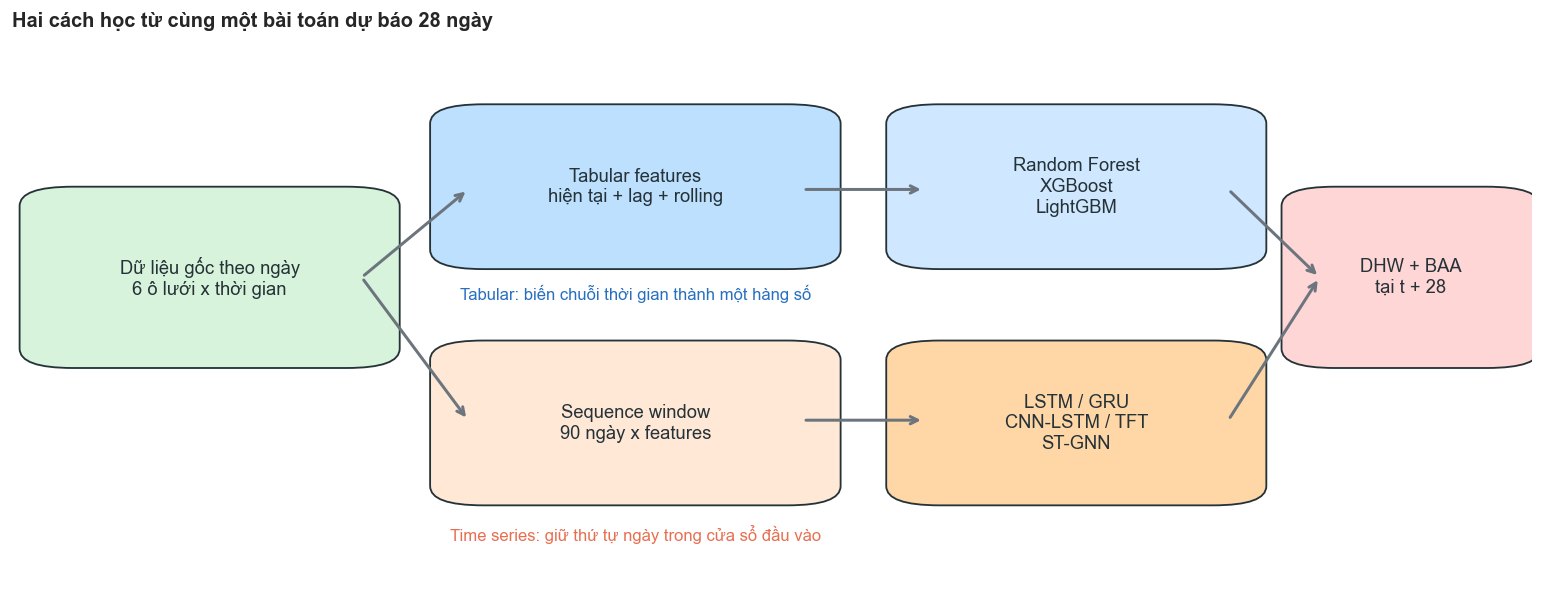

In [3]:

fig, ax = plt.subplots(figsize=(13, 5.2))
ax.axis("off")


def box(x, y, w, h, text, color, fontsize=11):
    rect = patches.FancyBboxPatch(
        (x, y), w, h,
        boxstyle="round,pad=0.025,rounding_size=0.035",
        facecolor=color,
        edgecolor=PALETTE["dark"],
        linewidth=1.1,
    )
    ax.add_patch(rect)
    ax.text(x + w / 2, y + h / 2, text, ha="center", va="center", fontsize=fontsize, color=PALETTE["dark"], wrap=True)

box(0.03, 0.44, 0.20, 0.28, "Dữ liệu gốc theo ngày\n6 ô lưới x thời gian", "#D8F3DC")
box(0.30, 0.62, 0.22, 0.25, "Tabular features\nhiện tại + lag + rolling", "#BDE0FE")
box(0.30, 0.19, 0.22, 0.25, "Sequence window\n90 ngày x features", "#FFE8D6")
box(0.60, 0.62, 0.20, 0.25, "Random Forest\nXGBoost\nLightGBM", "#CFE8FF")
box(0.60, 0.19, 0.20, 0.25, "LSTM / GRU\nCNN-LSTM / TFT\nST-GNN", "#FFD6A5")
box(0.86, 0.44, 0.12, 0.28, "DHW + BAA\ntại t + 28", "#FFD6D6")

arrow_kw = dict(arrowstyle="->", linewidth=1.8, color=PALETTE["gray"])
for y0, y1 in [(0.58, 0.74), (0.58, 0.32)]:
    ax.annotate("", xy=(0.30, y1), xytext=(0.23, y0), arrowprops=arrow_kw)
ax.annotate("", xy=(0.60, 0.74), xytext=(0.52, 0.74), arrowprops=arrow_kw)
ax.annotate("", xy=(0.60, 0.32), xytext=(0.52, 0.32), arrowprops=arrow_kw)
ax.annotate("", xy=(0.86, 0.58), xytext=(0.80, 0.74), arrowprops=arrow_kw)
ax.annotate("", xy=(0.86, 0.58), xytext=(0.80, 0.32), arrowprops=arrow_kw)

ax.text(0.41, 0.54, "Tabular: biến chuỗi thời gian thành một hàng số", ha="center", fontsize=10, color=PALETTE["blue"])
ax.text(0.41, 0.10, "Time series: giữ thứ tự ngày trong cửa sổ đầu vào", ha="center", fontsize=10, color=PALETTE["orange"])
ax.set_title("Hai cách học từ cùng một bài toán dự báo 28 ngày", loc="left")
savefig(fig, "01_tabular_vs_timeseries_overview.png")
plt.show()


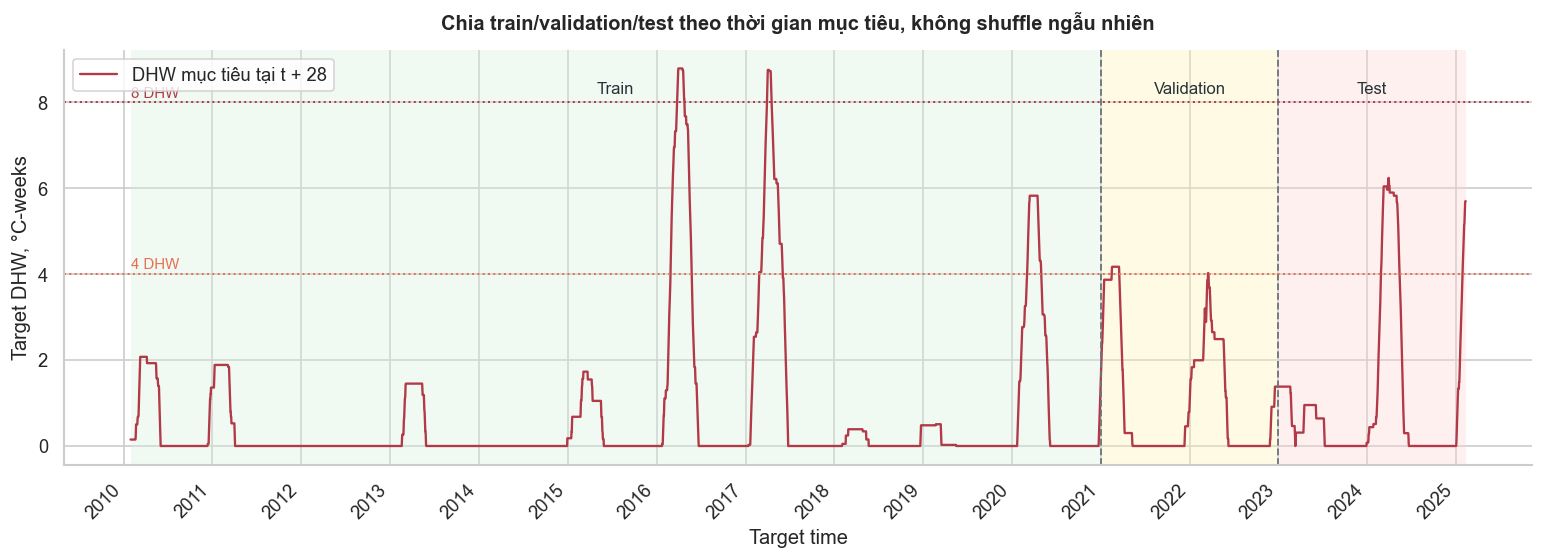

In [4]:

agg_target = agg.dropna(subset=[TARGET_DHW, TARGET_ALERT]).copy()
agg_target["target_time"] = agg_target[TARGET_TIME]

fig, ax = plt.subplots(figsize=(13, 4.8))
ax.plot(agg_target["target_time"], agg_target[TARGET_DHW], color=PALETTE["red"], linewidth=1.4, label="DHW mục tiêu tại t + 28")

x_min, x_max = agg_target["target_time"].min(), agg_target["target_time"].max()
regions = [
    (x_min, TRAIN_END, "Train", "#D8F3DC"),
    (TRAIN_END, VAL_END, "Validation", "#FFF3B0"),
    (VAL_END, x_max, "Test", "#FFD6D6"),
]
for start, end, label, color in regions:
    ax.axvspan(start, end, color=color, alpha=0.35, linewidth=0)
    ax.text(start + (end - start) / 2, ax.get_ylim()[1] * 0.92, label, ha="center", va="top", fontsize=10, color=PALETTE["dark"])

for cut in [TRAIN_END, VAL_END]:
    ax.axvline(cut, color=PALETTE["gray"], linestyle="--", linewidth=1.1)

for y, label, color in [(4, "4 DHW", PALETTE["orange"]), (8, "8 DHW", PALETTE["red"] )]:
    ax.axhline(y, color=color, linestyle=":", linewidth=1.2)
    ax.text(x_min, y + 0.12, label, color=color, fontsize=9)

ax.set_title("Chia train/validation/test theo thời gian mục tiêu, không shuffle ngẫu nhiên")
ax.set_ylabel("Target DHW, °C-weeks")
ax.set_xlabel("Target time")
ax.legend(loc="upper left")
ax.xaxis.set_major_locator(mdates.YearLocator(1))
ax.xaxis.set_major_formatter(mdates.DateFormatter("%Y"))
plt.setp(ax.get_xticklabels(), rotation=45, ha="right")
savefig(fig, "02_temporal_train_val_test_split.png")
plt.show()


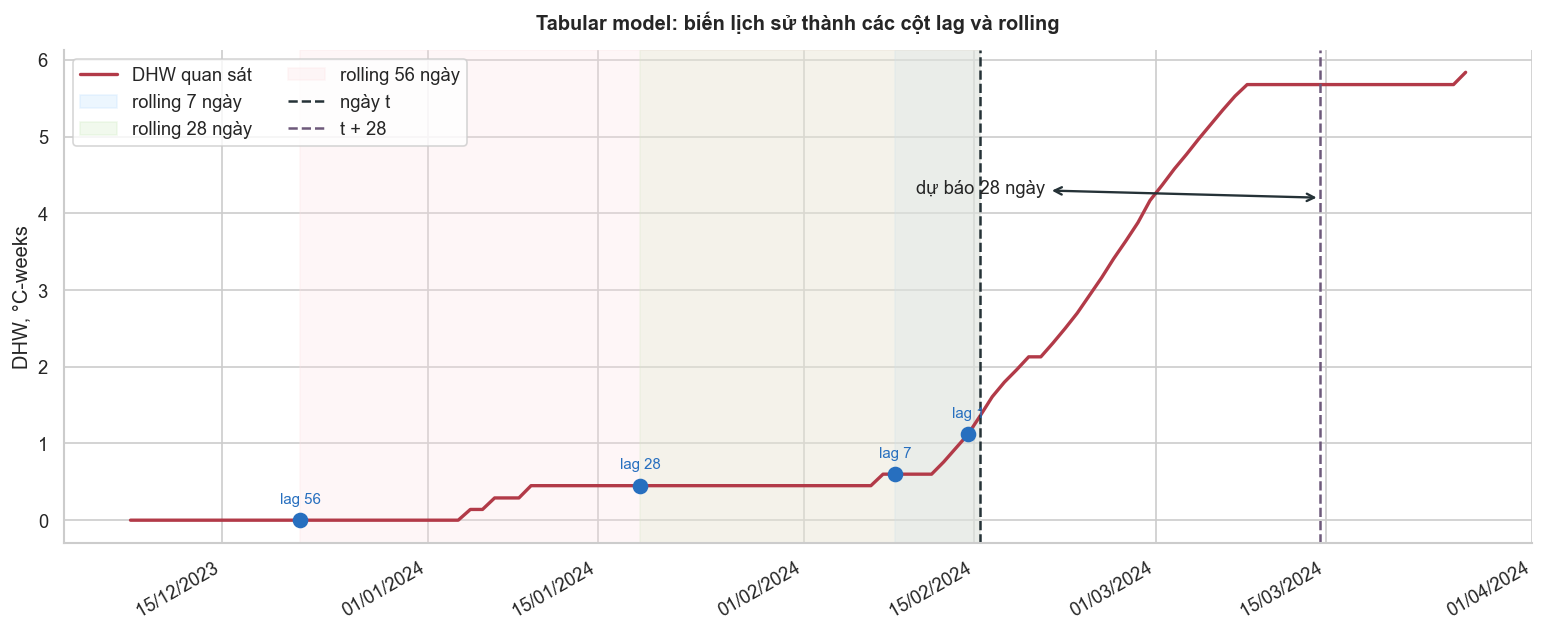

,Nhóm feature,Số lượng
0,Base/current features,6
1,Lag features,36
2,Rolling features,48
3,Calendar/alert/current derived,5
4,Total tabular feature columns,95


In [5]:

sample_node = 1
sample_time = pd.Timestamp("2024-02-15 12:00:00")
node_series = node[node["node_id"] == sample_node].sort_values("time").copy()
window = node_series[(node_series["time"] >= sample_time - pd.Timedelta(days=70)) & (node_series["time"] <= sample_time + pd.Timedelta(days=40))]
target_time = sample_time + pd.Timedelta(days=FORECAST_HORIZON)

fig, ax = plt.subplots(figsize=(13, 5.4))
ax.plot(window["time"], window["CRW_DHW"], color=PALETTE["red"], linewidth=2.0, label="DHW quan sát")

rolling_specs = [(7, "#BDE0FE"), (28, "#CDEAC0"), (56, "#FDE2E4")]
for days, color in rolling_specs:
    ax.axvspan(sample_time - pd.Timedelta(days=days), sample_time, color=color, alpha=0.28, label=f"rolling {days} ngày")

lag_days = [1, 7, 28, 56]
for lag in lag_days:
    lag_time = sample_time - pd.Timedelta(days=lag)
    y = node_series.loc[node_series["time"].eq(lag_time), "CRW_DHW"]
    if not y.empty:
        ax.scatter(lag_time, y.iloc[0], s=70, color=PALETTE["blue"], zorder=5)
        ax.text(lag_time, y.iloc[0] + 0.22, f"lag {lag}", ha="center", fontsize=9, color=PALETTE["blue"])

ax.axvline(sample_time, color=PALETTE["dark"], linestyle="--", linewidth=1.5, label="ngày t")
ax.axvline(target_time, color=PALETTE["purple"], linestyle="--", linewidth=1.5, label="t + 28")
ax.annotate("dự báo 28 ngày", xy=(target_time, window["CRW_DHW"].max()*0.72), xytext=(sample_time, window["CRW_DHW"].max()*0.72), arrowprops=dict(arrowstyle="<->", color=PALETTE["dark"], linewidth=1.4), ha="center", va="bottom")

ax.set_title("Tabular model: biến lịch sử thành các cột lag và rolling")
ax.set_ylabel("DHW, °C-weeks")
ax.set_xlabel("")
ax.legend(loc="upper left", ncol=2)
ax.xaxis.set_major_formatter(mdates.DateFormatter("%d/%m/%Y"))
plt.setp(ax.get_xticklabels(), rotation=30, ha="right")
savefig(fig, "03_tabular_lag_rolling_features.png")
plt.show()

display(feature_counts)


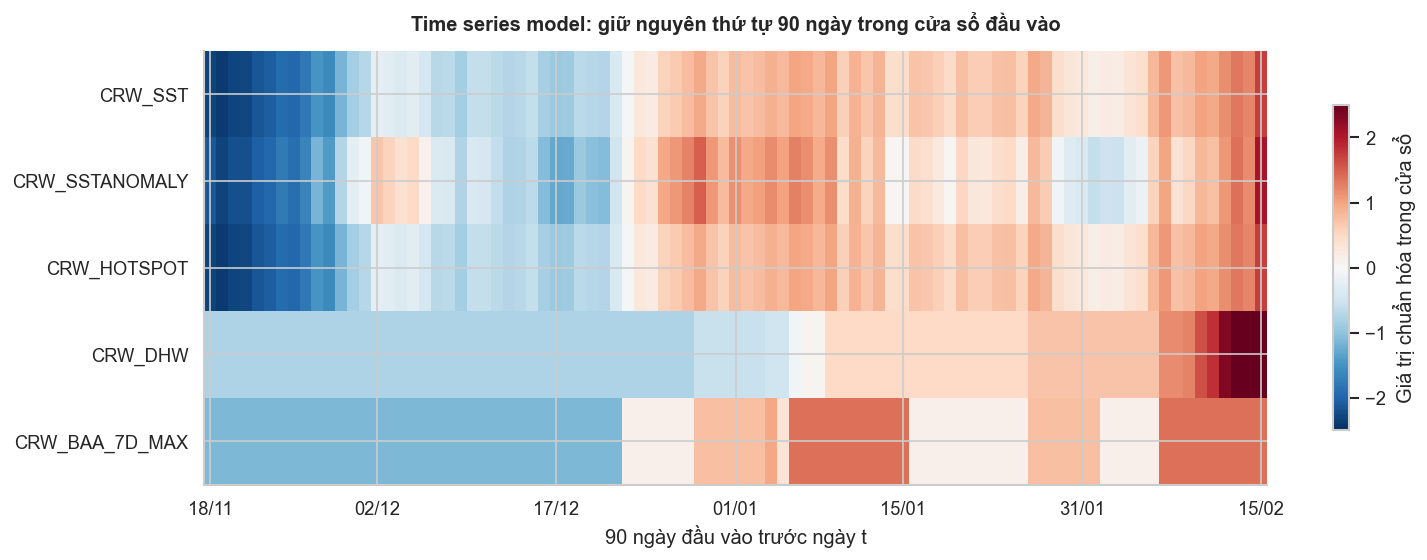

,Nhóm,Dạng input/output
0,Aggregate sequence models,samples x 90 ngày x features
1,ST-GNN,samples x 90 ngày x 6 nodes x features
2,Target,DHW và alert level tại t + 28


In [6]:

sequence_end = sample_time
sequence_start = sequence_end - pd.Timedelta(days=SEQUENCE_LENGTH - 1)
seq = agg[(agg["time"] >= sequence_start) & (agg["time"] <= sequence_end)].sort_values("time").copy()
seq_features = ["CRW_SST", "CRW_SSTANOMALY", "CRW_HOTSPOT", "CRW_DHW", "CRW_BAA_7D_MAX"]
seq_values = seq[seq_features].to_numpy(dtype=float)
seq_z = (seq_values - np.nanmean(seq_values, axis=0)) / np.nanstd(seq_values, axis=0)
seq_z = np.nan_to_num(seq_z)

fig, ax = plt.subplots(figsize=(13, 4.8))
im = ax.imshow(seq_z.T, aspect="auto", cmap="RdBu_r", vmin=-2.5, vmax=2.5)
ax.set_yticks(range(len(seq_features)))
ax.set_yticklabels(seq_features)
xticks = np.linspace(0, len(seq) - 1, 7, dtype=int)
ax.set_xticks(xticks)
ax.set_xticklabels([seq.iloc[i]["time"].strftime("%d/%m") for i in xticks])
ax.set_xlabel("90 ngày đầu vào trước ngày t")
ax.set_title("Time series model: giữ nguyên thứ tự 90 ngày trong cửa sổ đầu vào")
fig.colorbar(im, ax=ax, shrink=0.75, label="Giá trị chuẩn hóa trong cửa sổ")
savefig(fig, "04_sequence_window_heatmap.png")
plt.show()

sequence_shape = pd.DataFrame([
    ("Aggregate sequence models", f"samples x {SEQUENCE_LENGTH} ngày x features"),
    ("ST-GNN", f"samples x {SEQUENCE_LENGTH} ngày x 6 nodes x features"),
    ("Target", "DHW và alert level tại t + 28"),
], columns=["Nhóm", "Dạng input/output"])
display(sequence_shape)


## 2. Các Nhóm Model Trong Repo

Các cell bên dưới tạo bảng/sơ đồ model families và so sánh hiệu năng bằng leaderboard.

,Model,Family,Ý tưởng,Điểm cần giảng
0,Random Forest,tabular,Nhiều cây quyết định học song song,"Ổn định, dễ xem feature importance"
1,XGBoost,tabular,Boosting cây quyết định,"Mạnh cho dữ liệu bảng, học quan hệ phi tuyến"
2,LightGBM,tabular,Boosting cây quyết định tối ưu tốc độ,"Nhanh, hỗ trợ class_weight balanced"
3,LSTM,time series,RNN có bộ nhớ dài/ngắn,Giữ thứ tự ngày trong chuỗi
4,GRU,time series,RNN gọn hơn LSTM,"Ít cổng hơn, thường train nhanh hơn"
5,CNN-LSTM,time series,"CNN bắt pattern cục bộ, LSTM đọc chuỗi",Hữu ích khi có motif ngắn hạn
6,TFT-lite,time series,Transformer attention gọn,Học quan hệ xa trong cửa sổ 90 ngày
7,ST-GNN,spatio-temporal,Lan truyền thông tin qua graph 6 node,Kết hợp thời gian và không gian


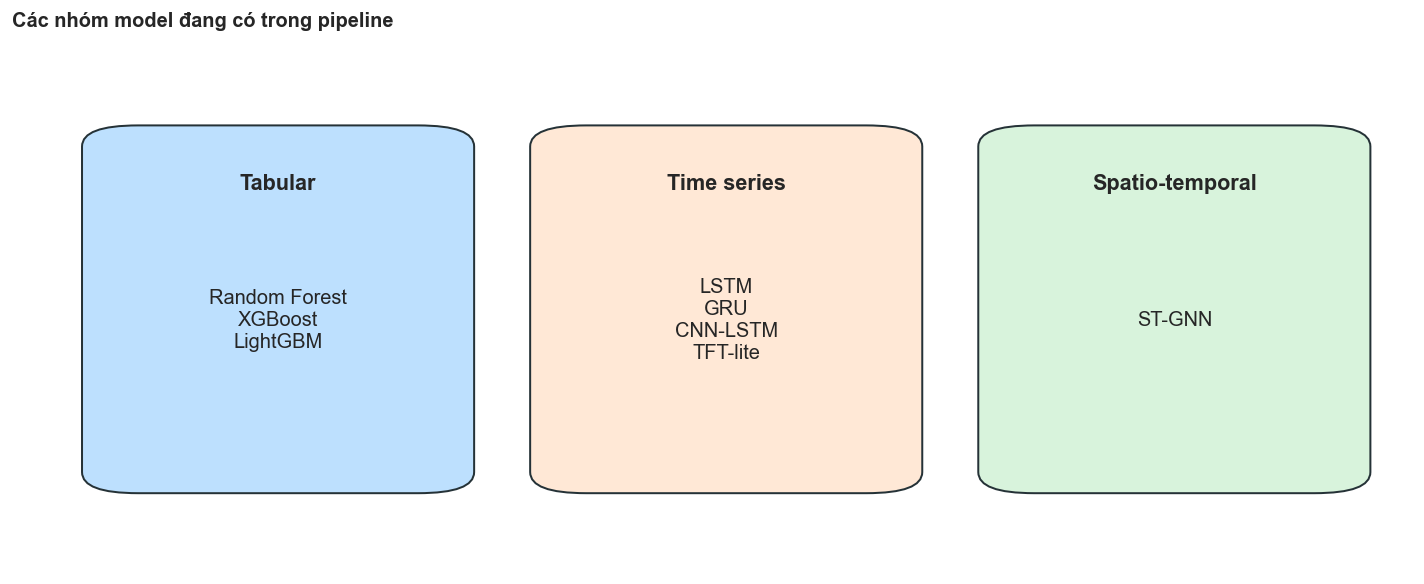

In [7]:

model_family_table = pd.DataFrame([
    ("Random Forest", "tabular", "Nhiều cây quyết định học song song", "Ổn định, dễ xem feature importance"),
    ("XGBoost", "tabular", "Boosting cây quyết định", "Mạnh cho dữ liệu bảng, học quan hệ phi tuyến"),
    ("LightGBM", "tabular", "Boosting cây quyết định tối ưu tốc độ", "Nhanh, hỗ trợ class_weight balanced"),
    ("LSTM", "time series", "RNN có bộ nhớ dài/ngắn", "Giữ thứ tự ngày trong chuỗi"),
    ("GRU", "time series", "RNN gọn hơn LSTM", "Ít cổng hơn, thường train nhanh hơn"),
    ("CNN-LSTM", "time series", "CNN bắt pattern cục bộ, LSTM đọc chuỗi", "Hữu ích khi có motif ngắn hạn"),
    ("TFT-lite", "time series", "Transformer attention gọn", "Học quan hệ xa trong cửa sổ 90 ngày"),
    ("ST-GNN", "spatio-temporal", "Lan truyền thông tin qua graph 6 node", "Kết hợp thời gian và không gian"),
], columns=["Model", "Family", "Ý tưởng", "Điểm cần giảng"])

display(model_family_table)

fig, ax = plt.subplots(figsize=(12, 5))
ax.axis("off")
columns = [("Tabular", 0.08, ["Random Forest", "XGBoost", "LightGBM"], "#BDE0FE"), ("Time series", 0.40, ["LSTM", "GRU", "CNN-LSTM", "TFT-lite"], "#FFE8D6"), ("Spatio-temporal", 0.72, ["ST-GNN"], "#D8F3DC")]
for title, x, items, color in columns:
    box = patches.FancyBboxPatch((x, 0.18), 0.22, 0.64, boxstyle="round,pad=0.03,rounding_size=0.04", facecolor=color, edgecolor=PALETTE["dark"], linewidth=1.2)
    ax.add_patch(box)
    ax.text(x + 0.11, 0.74, title, ha="center", va="center", fontsize=13, fontweight="bold")
    ax.text(x + 0.11, 0.48, "\n".join(items), ha="center", va="center", fontsize=12)
ax.set_title("Các nhóm model đang có trong pipeline", loc="left")
savefig(fig, "05_model_families.png")
plt.show()


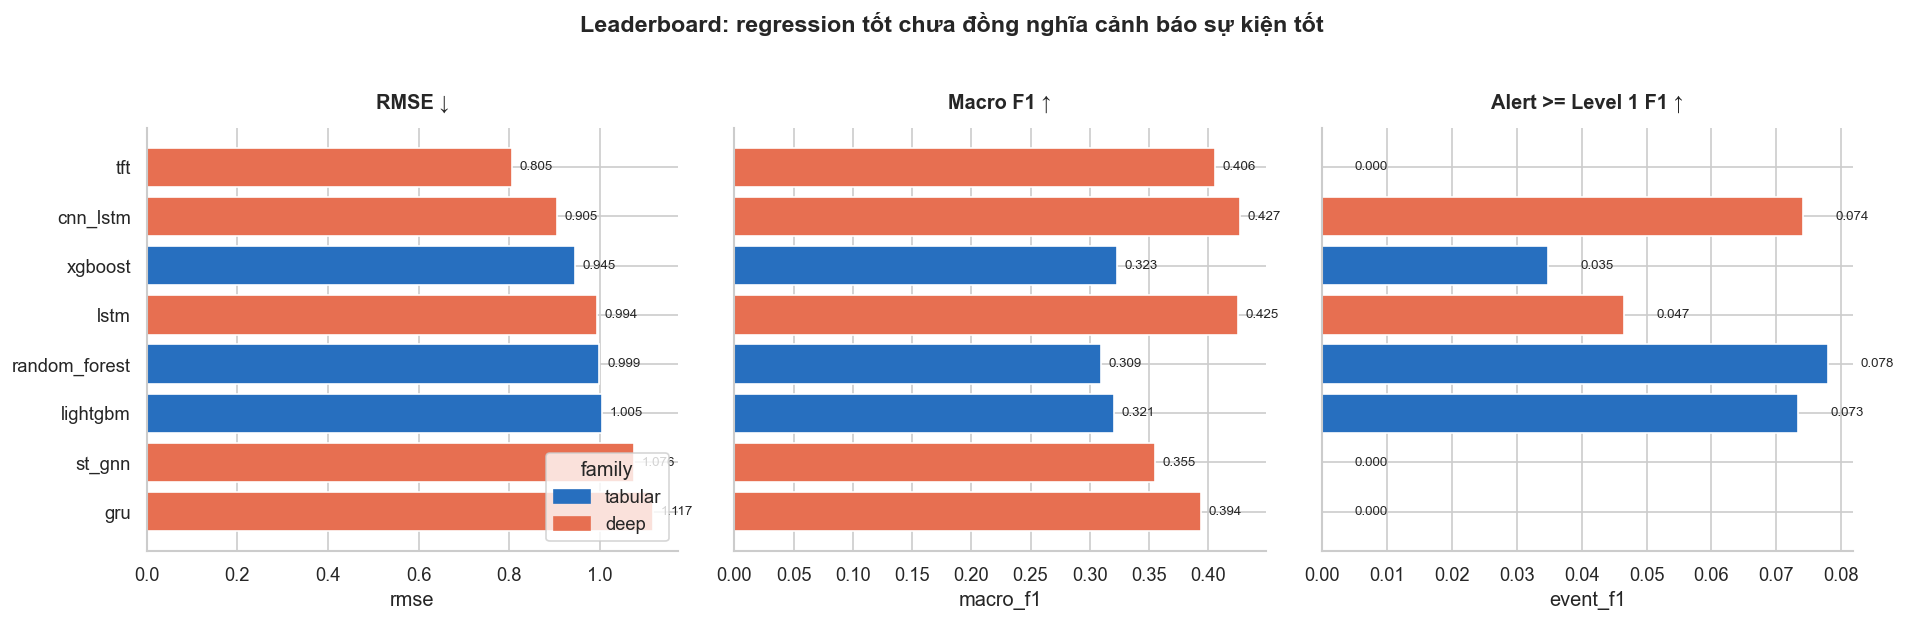

In [8]:

lb = leaderboard.copy()
lb["family_color"] = lb["family"].map(FAMILY_COLORS)
order = lb.sort_values("rmse")["model"].tolist()

fig, axes = plt.subplots(1, 3, figsize=(16, 5), sharey=True)
metrics = [("rmse", "RMSE ↓"), ("macro_f1", "Macro F1 ↑"), ("event_f1", "Alert >= Level 1 F1 ↑")]
for ax, (metric, title) in zip(axes, metrics):
    data = lb.set_index("model").loc[order].reset_index()
    ax.barh(data["model"], data[metric], color=data["family"].map(FAMILY_COLORS))
    ax.invert_yaxis()
    ax.set_title(title)
    ax.set_xlabel(metric)
    ax.set_ylabel("")
    for i, v in enumerate(data[metric]):
        ax.text(v + max(data[metric].max() * 0.015, 0.005), i, f"{v:.3f}", va="center", fontsize=8)

handles = [patches.Patch(color=color, label=family) for family, color in FAMILY_COLORS.items()]
axes[0].legend(handles=handles, title="family", loc="lower right")
fig.suptitle("Leaderboard: regression tốt chưa đồng nghĩa cảnh báo sự kiện tốt", y=1.03, fontsize=14, fontweight="bold")
savefig(fig, "06_leaderboard_rmse_macro_event.png")
plt.show()


## 3. Đọc Dự Đoán Và Lỗi Model

Các cell trong phần này so sánh dự đoán theo thời gian, scatter predicted-vs-actual, confusion matrix, event metrics, training curves và feature importance.

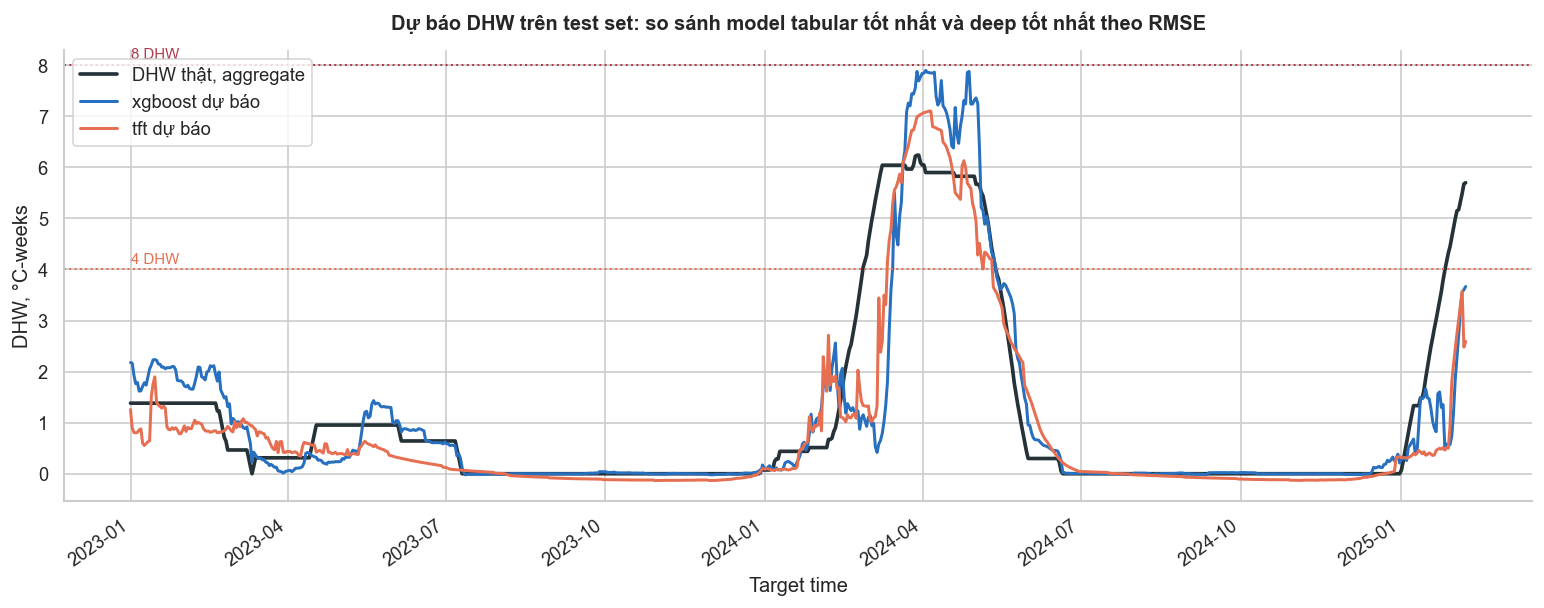

Best tabular by RMSE: xgboost
Best deep by RMSE: tft
Best deep by macro F1: cnn_lstm


In [9]:

best_tabular = leaderboard[leaderboard["family"].eq("tabular")].sort_values("rmse").iloc[0]["model"]
best_deep_rmse = leaderboard[leaderboard["family"].eq("deep")].sort_values("rmse").iloc[0]["model"]
best_deep_f1 = leaderboard[leaderboard["family"].eq("deep")].sort_values("macro_f1", ascending=False).iloc[0]["model"]

truth = agg.dropna(subset=[TARGET_DHW]).copy()
truth["target_time"] = truth[TARGET_TIME]
truth = truth[(truth["target_time"] >= pd.Timestamp("2022-12-31")) & (truth["target_time"] <= pd.Timestamp("2025-02-08"))]
truth = truth[["target_time", TARGET_DHW]].rename(columns={TARGET_DHW: "truth_dhw"})

def average_prediction(model):
    pred = predictions[model].copy()
    return pred.groupby("target_time", as_index=False).agg(
        y_dhw_pred=("y_dhw_pred", "mean"),
        y_dhw_true=("y_dhw_true", "mean"),
    )

tab_pred = average_prediction(best_tabular).rename(columns={"y_dhw_pred": f"{best_tabular}_pred"})
deep_pred = average_prediction(best_deep_rmse).rename(columns={"y_dhw_pred": f"{best_deep_rmse}_pred"})
plot_df = truth.merge(tab_pred[["target_time", f"{best_tabular}_pred"]], on="target_time", how="left").merge(deep_pred[["target_time", f"{best_deep_rmse}_pred"]], on="target_time", how="left")

fig, ax = plt.subplots(figsize=(13, 5.2))
ax.plot(plot_df["target_time"], plot_df["truth_dhw"], color=PALETTE["dark"], linewidth=2.2, label="DHW thật, aggregate")
ax.plot(plot_df["target_time"], plot_df[f"{best_tabular}_pred"], color=PALETTE["blue"], linewidth=1.8, label=f"{best_tabular} dự báo")
ax.plot(plot_df["target_time"], plot_df[f"{best_deep_rmse}_pred"], color=PALETTE["orange"], linewidth=1.8, label=f"{best_deep_rmse} dự báo")
for y, label, color in [(4, "4 DHW", PALETTE["orange"]), (8, "8 DHW", PALETTE["red"] )]:
    ax.axhline(y, color=color, linestyle=":", linewidth=1.2)
    ax.text(plot_df["target_time"].min(), y + 0.12, label, color=color, fontsize=9)
ax.set_title("Dự báo DHW trên test set: so sánh model tabular tốt nhất và deep tốt nhất theo RMSE")
ax.set_ylabel("DHW, °C-weeks")
ax.set_xlabel("Target time")
ax.legend(loc="upper left")
ax.xaxis.set_major_formatter(mdates.DateFormatter("%Y-%m"))
plt.setp(ax.get_xticklabels(), rotation=35, ha="right")
savefig(fig, "07_test_predictions_timeseries.png")
plt.show()

print(f"Best tabular by RMSE: {best_tabular}")
print(f"Best deep by RMSE: {best_deep_rmse}")
print(f"Best deep by macro F1: {best_deep_f1}")


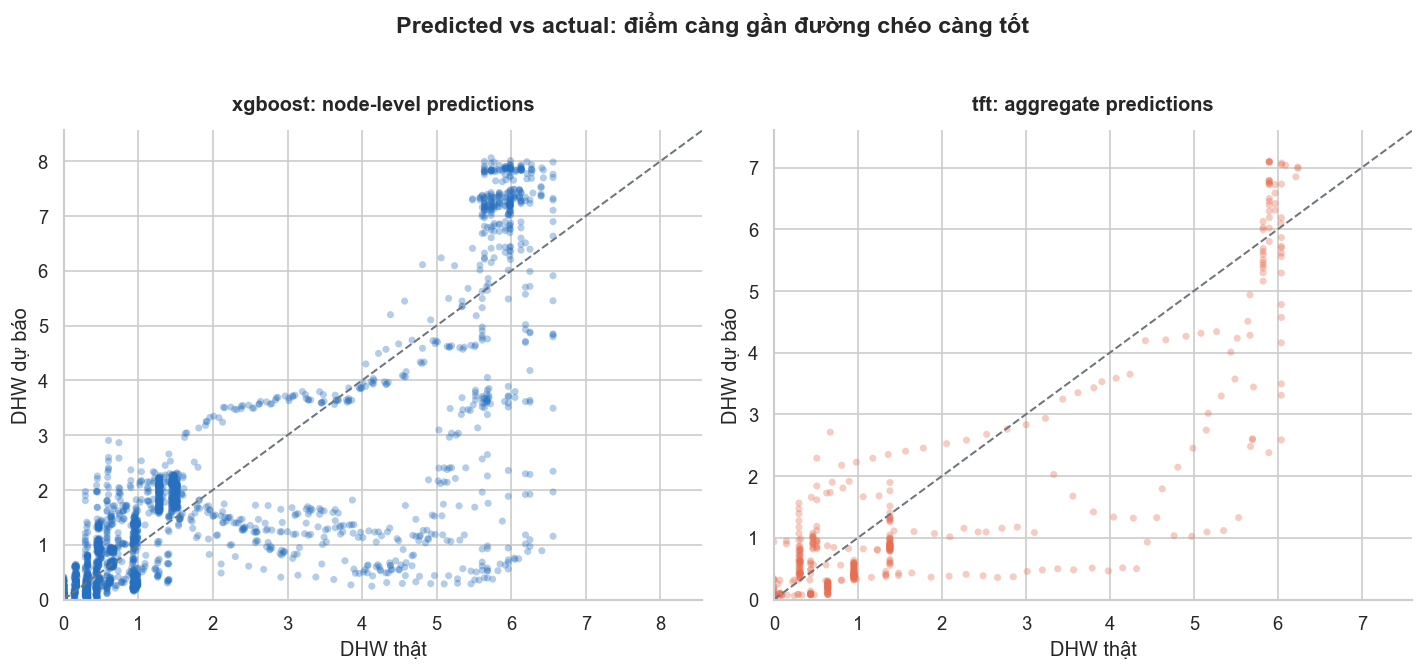

In [10]:

def scatter_panel(ax, model, title, aggregate=False):
    pred = predictions[model].copy()
    if aggregate:
        pred = pred.groupby("target_time", as_index=False).agg(y_dhw_true=("y_dhw_true", "mean"), y_dhw_pred=("y_dhw_pred", "mean"))
    ax.scatter(pred["y_dhw_true"], pred["y_dhw_pred"], s=18, alpha=0.35, color=PALETTE["blue"] if leaderboard.set_index("model").loc[model, "family"] == "tabular" else PALETTE["orange"], edgecolors="none")
    lim_max = max(pred["y_dhw_true"].max(), pred["y_dhw_pred"].max()) + 0.5
    ax.plot([0, lim_max], [0, lim_max], color=PALETTE["gray"], linestyle="--", linewidth=1.2)
    ax.set_xlim(0, lim_max)
    ax.set_ylim(0, lim_max)
    ax.set_xlabel("DHW thật")
    ax.set_ylabel("DHW dự báo")
    ax.set_title(title)

fig, axes = plt.subplots(1, 2, figsize=(12, 5.4))
scatter_panel(axes[0], best_tabular, f"{best_tabular}: node-level predictions", aggregate=False)
scatter_panel(axes[1], best_deep_rmse, f"{best_deep_rmse}: aggregate predictions", aggregate=True)
fig.suptitle("Predicted vs actual: điểm càng gần đường chéo càng tốt", y=1.03, fontsize=14, fontweight="bold")
savefig(fig, "08_predicted_vs_actual_scatter.png")
plt.show()


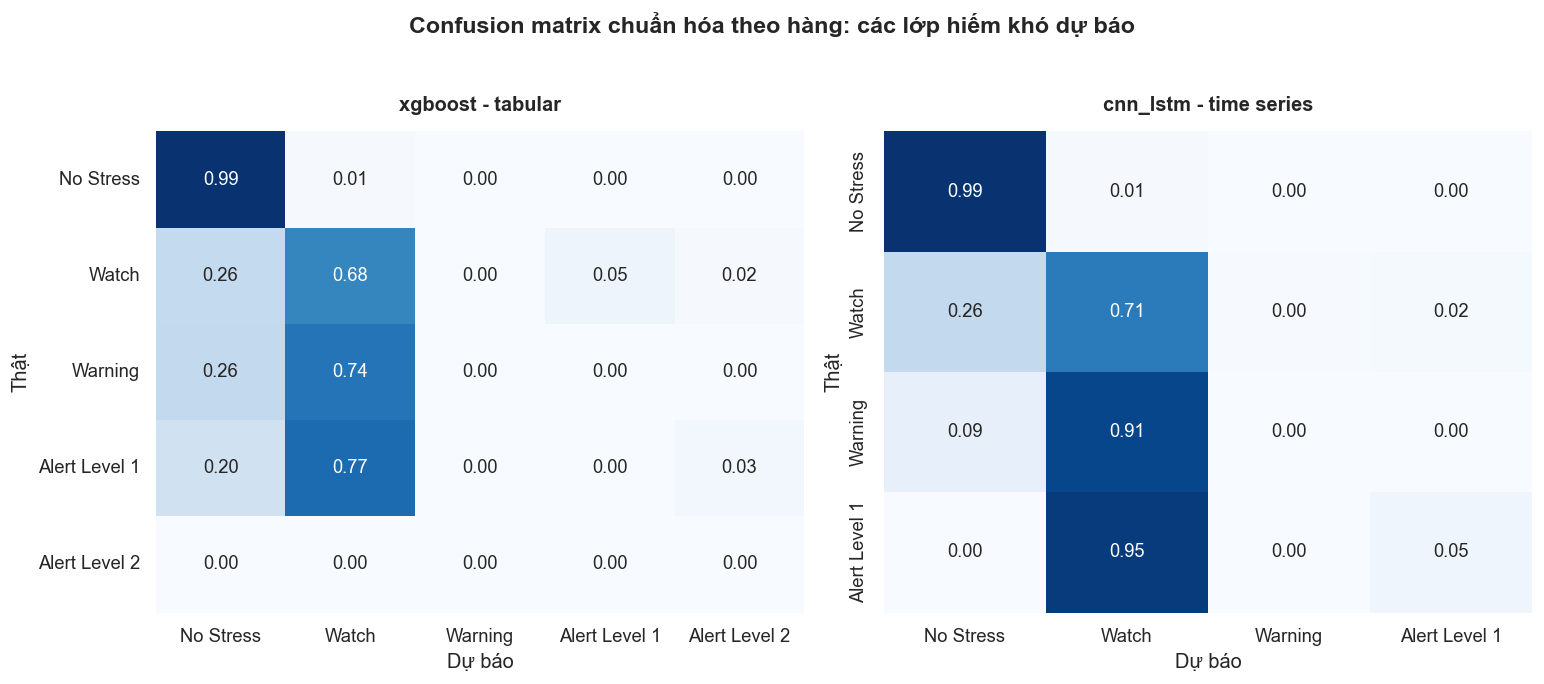

In [11]:

def plot_normalized_cm(ax, model, title):
    pred = predictions[model]
    labels = sorted(set(pred["y_alert_true"].astype(int)) | set(pred["y_alert_pred"].astype(int)) | {0, 1, 2, 3})
    cm = confusion_matrix(pred["y_alert_true"].astype(int), pred["y_alert_pred"].astype(int), labels=labels)
    row_sums = cm.sum(axis=1, keepdims=True)
    cm_norm = np.divide(cm, np.maximum(row_sums, 1), where=row_sums != 0)
    sns.heatmap(cm_norm, annot=True, fmt=".2f", cmap="Blues", vmin=0, vmax=1, ax=ax, cbar=False, xticklabels=[ALERT_LABELS.get(i, str(i)) for i in labels], yticklabels=[ALERT_LABELS.get(i, str(i)) for i in labels])
    ax.set_xlabel("Dự báo")
    ax.set_ylabel("Thật")
    ax.set_title(title)

classification_tabular = leaderboard[leaderboard["family"].eq("tabular")].sort_values("macro_f1", ascending=False).iloc[0]["model"]
classification_deep = leaderboard[leaderboard["family"].eq("deep")].sort_values("macro_f1", ascending=False).iloc[0]["model"]

fig, axes = plt.subplots(1, 2, figsize=(13, 5.5))
plot_normalized_cm(axes[0], classification_tabular, f"{classification_tabular} - tabular")
plot_normalized_cm(axes[1], classification_deep, f"{classification_deep} - time series")
fig.suptitle("Confusion matrix chuẩn hóa theo hàng: các lớp hiếm khó dự báo", y=1.03, fontsize=14, fontweight="bold")
savefig(fig, "09_confusion_matrices.png")
plt.show()


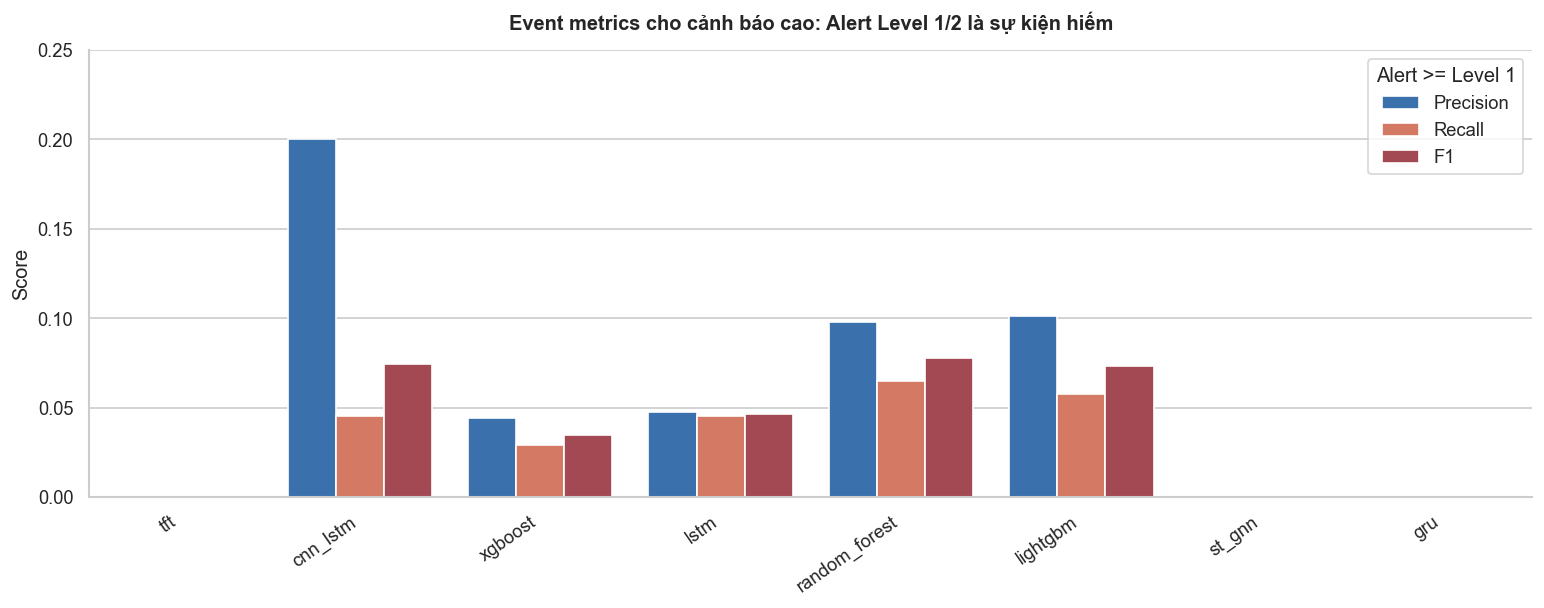

In [12]:

event_cols = ["event_precision", "event_recall", "event_f1"]
event_long = leaderboard.melt(id_vars=["model", "family"], value_vars=event_cols, var_name="metric", value_name="score")
metric_labels = {"event_precision": "Precision", "event_recall": "Recall", "event_f1": "F1"}
event_long["metric"] = event_long["metric"].map(metric_labels)

fig, ax = plt.subplots(figsize=(13, 5.2))
sns.barplot(data=event_long, x="model", y="score", hue="metric", ax=ax, palette=[PALETTE["blue"], PALETTE["orange"], PALETTE["red"]])
ax.set_title("Event metrics cho cảnh báo cao: Alert Level 1/2 là sự kiện hiếm")
ax.set_ylabel("Score")
ax.set_xlabel("")
ax.set_ylim(0, max(0.25, event_long["score"].max() * 1.25))
plt.setp(ax.get_xticklabels(), rotation=35, ha="right")
ax.legend(title="Alert >= Level 1")
savefig(fig, "10_event_precision_recall_f1.png")
plt.show()


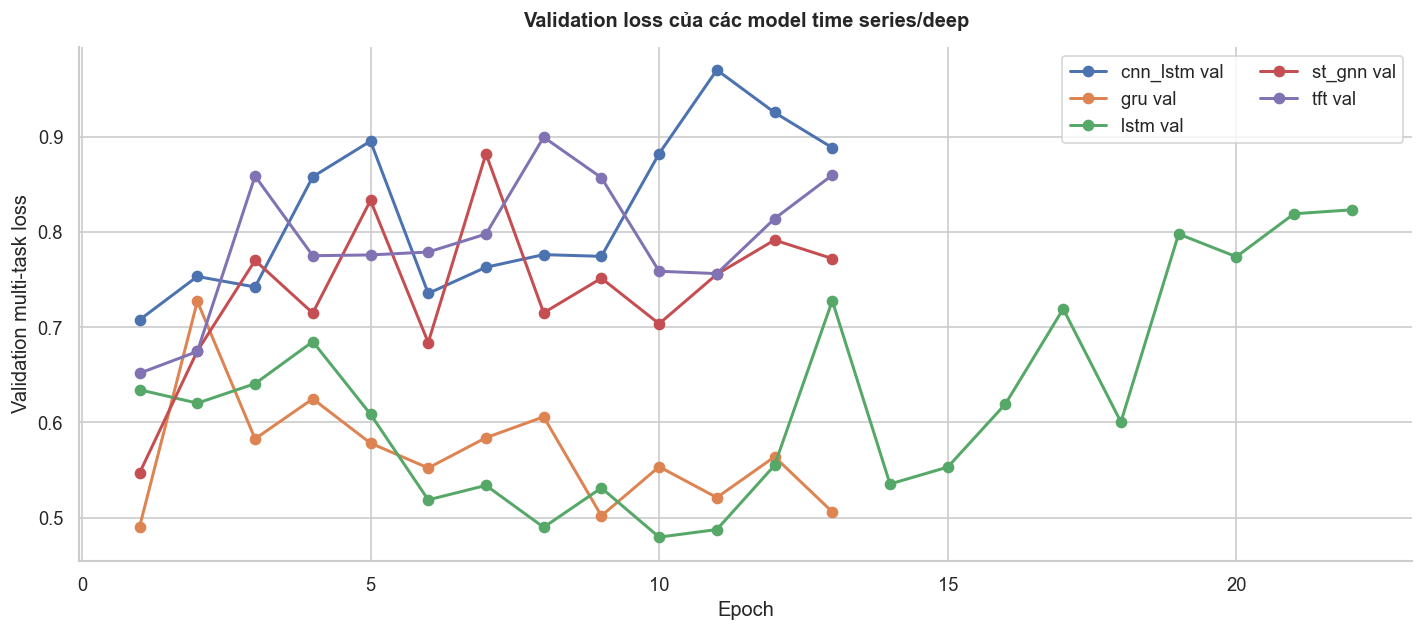

,model,epochs_run,best_epoch,best_val_loss
2,lstm,22,10,0.4794
1,gru,13,1,0.4904
3,st_gnn,13,1,0.5469
4,tft,13,1,0.6517
0,cnn_lstm,13,1,0.7078


In [13]:

fig, ax = plt.subplots(figsize=(12, 5.4))
for model, hist in sorted(histories.items()):
    if hist.empty or "val_loss" not in hist:
        continue
    ax.plot(hist["epoch"], hist["val_loss"], marker="o", linewidth=1.8, label=f"{model} val")
ax.set_title("Validation loss của các model time series/deep")
ax.set_xlabel("Epoch")
ax.set_ylabel("Validation multi-task loss")
ax.legend(ncol=2)
savefig(fig, "11_deep_training_curves.png")
plt.show()

history_summary = []
for model, hist in histories.items():
    if hist.empty or "val_loss" not in hist:
        continue
    best_idx = hist["val_loss"].idxmin()
    history_summary.append({
        "model": model,
        "epochs_run": int(hist["epoch"].max()),
        "best_epoch": int(hist.loc[best_idx, "epoch"]),
        "best_val_loss": float(hist.loc[best_idx, "val_loss"]),
    })
display(pd.DataFrame(history_summary).sort_values("best_val_loss").round(4))


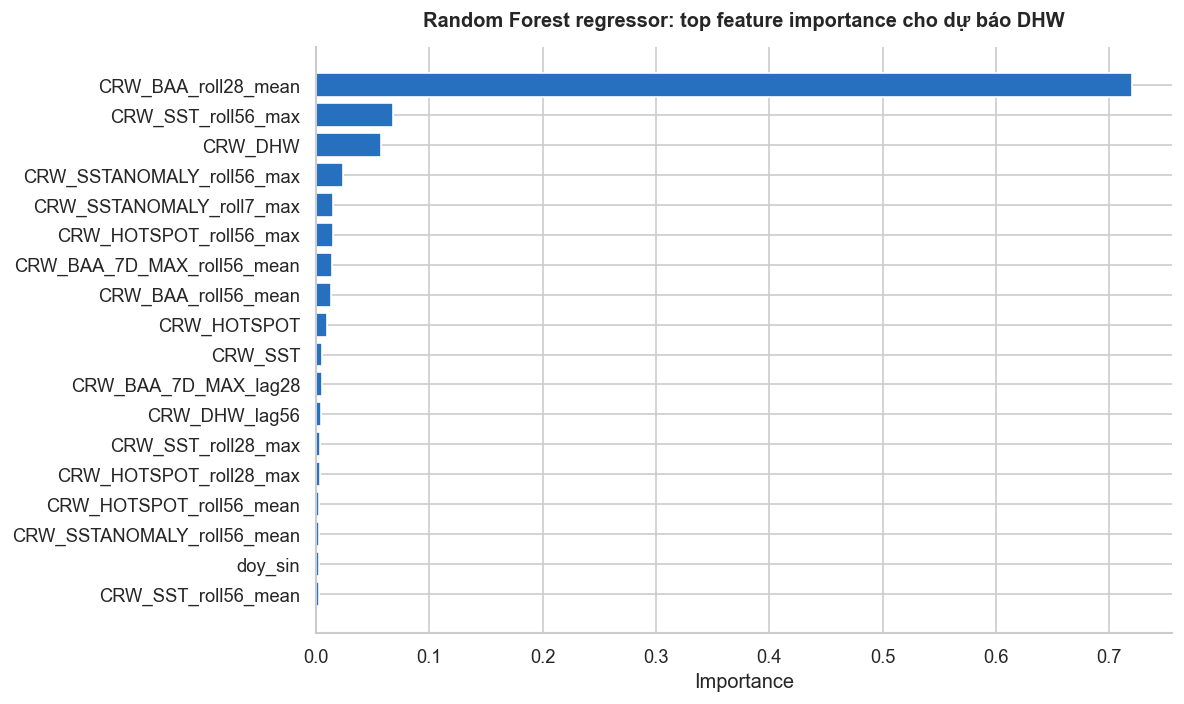

,feature,importance
0,CRW_BAA_roll28_mean,0.719623
1,CRW_SST_roll56_max,0.068320
2,CRW_DHW,0.057583
3,CRW_SSTANOMALY_roll56_max,0.023458
4,CRW_SSTANOMALY_roll7_max,0.015405
5,CRW_HOTSPOT_roll56_max,0.015381
6,CRW_BAA_7D_MAX_roll56_mean,0.014218
7,CRW_BAA_roll56_mean,0.012830
8,CRW_HOTSPOT,0.009863
9,CRW_SST,0.005335


In [14]:

try:
    from joblib import load
    with warnings.catch_warnings():
        warnings.simplefilter("ignore")
        rf_reg = load(MODEL_DIR / "random_forest_regressor.joblib")
    importances = pd.DataFrame({"feature": TABULAR_FEATURE_COLS, "importance": rf_reg.feature_importances_})
    importances = importances.sort_values("importance", ascending=False).head(18)

    fig, ax = plt.subplots(figsize=(10, 6))
    ax.barh(importances["feature"][::-1], importances["importance"][::-1], color=PALETTE["blue"])
    ax.set_title("Random Forest regressor: top feature importance cho dự báo DHW")
    ax.set_xlabel("Importance")
    ax.set_ylabel("")
    savefig(fig, "12_tabular_feature_importance.png")
    plt.show()
    display(importances.reset_index(drop=True))
except Exception as exc:
    display(Markdown(f"Không đọc được Random Forest feature importance: `{type(exc).__name__}: {exc}`"))


## Tài Liệu Giải Thích

Xem file [modeling_tabular_timeseries_lecture_guide.md](modeling_tabular_timeseries_lecture_guide.md) để đọc phần giải thích đầy đủ và hướng dẫn phân tích từng biểu đồ cho học sinh.